In [1]:
%pip install pandas numpy scikit-learn openpyxl matplotlib joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\andrei\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


## 1. Загрузка данных

In [3]:
diag = pd.read_csv("ДиагРабота.csv", low_memory=False)
svod = pd.read_excel("Свод_КИМ_НИКО-22.xlsx")

print("ДиагРабота:", diag.shape)
print("Свод:", svod.shape)

ДиагРабота: (44367, 173)
Свод: (44567, 35)


In [4]:
print("Колонки ДиагРабота:")
print(diag.columns.tolist())

print("\nКолонки Свод_КИМ_НИКО-22:")
print(svod.columns.tolist())

Колонки ДиагРабота:
['ID', '№', 'Класс', 'ПБ', 'Проц_вып', 'Проц_вып_к', 'Логин_ОО', 'ТИП_НП', 'Размер_НП', 'Пол', 'Отметка_РУ', 'Отметка_МА', 'ДР1.1', 'ДР1.2_1', 'ДР1.2_2', 'ДР1.2_3', 'ДР1.2_4', 'ДР1.2_5', 'ДР1.2_6', 'ДР1.2_7', 'ДР1.2_8', 'ДР1.2_9', 'ДР2', 'ДР3.1', 'ДР3.2_0', 'ДР3.2_1', 'ДР3.2_2', 'ДР3.2_3', 'ДР3.2_4', 'ДР3.2_5', 'ДР4_1', 'ДР4_2', 'ДР4_3', 'ДР4_4', 'ДР4_5', 'ДР4_6', 'ДР4_7', 'ДР4_8', 'ДР5', 'ДР6.1', 'ДР6.2_1', 'ДР6.2_2', 'ДР6.2_3', 'ДР6.2_4', 'ДР6.2_5', 'ДР6.2_6', 'ДР6.2_7', 'ДР6.3', 'ДР7.1', 'ДР7.2_0', 'ДР7.2_1', 'ДР7.2_2', 'ДР7.2_3', 'ДР7.2_4', 'ДР7.2_5', 'ДР7.2_6', 'ДР8.1', 'ДР8.2_1', 'ДР8.2_2', 'ДР8.2_3', 'ДР8.2_4', 'ДР8.2_5', 'ДР8.2_6', 'ДР9.1', 'ДР9.2_0', 'ДР9.2_1', 'ДР9.2_2', 'ДР9.2_3', 'ДР9.2_4', 'ДР9.2_5', 'ДР10.1', 'ДР10.2_0', 'ДР10.2_1', 'ДР10.2_2', 'ДР10.2_3', 'ДР10.2_4', 'ДР10.2_5', 'ДР10.2_6', 'Безопасность', 'Bul24', 'Bul25', 'Ref26', 'Vz27', 'Blag28', 'Blag29', 'Blag30', 'Blag31', 'Dev32', 'Dev33', 'Dev34', 'Dev35', 'Dev36', 'Dev37', 'Bul24_к3', 'Bul25

## 2. Объединение таблиц по полю `№`

In [5]:
diag["№"] = diag["№"].astype(str).str.strip()
svod["№"] = svod["№"].astype(str).str.strip()

print("Уникальных № в diag:", diag["№"].nunique())
print("Уникальных № в svod:", svod["№"].nunique())

print("Дубликаты № в diag:", diag["№"].duplicated().sum())
print("Дубликаты № в svod:", svod["№"].duplicated().sum())

common_ids = set(diag["№"]) & set(svod["№"])
print("Общих №:", len(common_ids))

Уникальных № в diag: 44367
Уникальных № в svod: 44367
Дубликаты № в diag: 0
Дубликаты № в svod: 200
Общих №: 44367


In [6]:
df = diag.merge(svod, on="№", how="inner", suffixes=("_diag", "_svod"))
print("После merge:", df.shape)
df.head()

После merge: (44567, 207)


,ID,№,Класс_diag,ПБ,Проц_вып,Проц_вып_к,Логин_ОО,ТИП_НП,Размер_НП,Пол_diag,...,7(2),Какими военными победами нашей страны Вы гордитесь?,8(1),8(2),"Каковы наиболее важные, на Ваш взгляд, научные открытия и технические достижения учёных нашей страны?",9(1),9(2),Какие российские деятели искусства прошлого и настоящего известны всему миру?,10(1),10(2)
0,edu233449_niko08_041,2092082,8,14,73.684211,4,edu233449,2,4,2,...,379.0,"в ВОВ, первая мировая, русско-турецкая",1.0,178,открытие Сибири,2.0,8.0,"Ленин, Сталин, Пржевальский, Пушкин, Есенин, Г...",1.0,12.0
1,edu233954_niko08_110,2134165,8,11,57.894737,3,edu233954,1,8,2,...,NaN,я не горжусь россией,4.0,NaN,полет в космос,2.0,1.0,"пушкин , достоевский , толстой , лермонтов, че...",1.0,12.0
2,edu050016_niko06_061,1989019,6,11,57.894737,3,edu050016,1,7,1,...,1.0,Великой отечественной войне.,2.0,1,"полёт гагарина в космос,таблица менделеева.",2.0,12.0,"Андрей Рублёв,Мая Плесецская.",2.0,96.0
3,edu110041_niko06_002,1952877,6,10,52.631579,3,edu110041,1,5,2,...,3.0,Я горжусь всеми военными победами нашей страны...,3.0,NaN,Полет Гагарина в космос,2.0,1.0,"Известные художники, композиторы, писатели",3.0,NaN
4,edu110041_niko08_007,2097069,8,8,42.105263,2,edu110041,1,5,2,...,1.0,"победой на Ледовом побоище, победой над нациск...",2.0,51,я не знаю,3.0,NaN,"Пушкин, Лермантов.",2.0,12.0


In [7]:
df.columns = df.columns.astype(str)

print("Типы имён колонок после приведения:")
print(set(type(c).__name__ for c in df.columns))
print("Первые 20 колонок:")
print(df.columns[:20].tolist())

Типы имён колонок после приведения:
{'str'}
Первые 20 колонок:
['ID', '№', 'Класс_diag', 'ПБ', 'Проц_вып', 'Проц_вып_к', 'Логин_ОО', 'ТИП_НП', 'Размер_НП', 'Пол_diag', 'Отметка_РУ', 'Отметка_МА', 'ДР1.1', 'ДР1.2_1', 'ДР1.2_2', 'ДР1.2_3', 'ДР1.2_4', 'ДР1.2_5', 'ДР1.2_6', 'ДР1.2_7']


## 3. Текстовые колонки из `Свод_КИМ_НИКО-22.xlsx`

In [8]:
text_cols = [
    "Расскажите немного о своей семье. Кто в неё входит? ",
    "Кем из членов семьи Вы гордитесь? Объясните, почему.",
    "Какие традиции существуют в Вашей семье?",
    "Что Вы обычно делаете вместе с другими членами семьи?",
    "Как называется Ваш населённый пункт?",
    "Какие достопримечательности есть в Вашем населённом пункте?",
    "Что, по Вашему мнению, необходимо сделать в первую очередь, чтобы улучшить жизнь в Вашем населённом пункте?",
    "Какими военными победами нашей страны Вы гордитесь?",
    "Каковы наиболее важные, на Ваш взгляд, научные открытия и технические достижения учёных нашей страны?",
    "Какие российские деятели искусства прошлого и настоящего известны всему миру?"
]

text_cols = [str(c) for c in text_cols]
existing_text_cols = [c for c in text_cols if c in df.columns]

print("Найдено текстовых колонок:", len(existing_text_cols))
print(existing_text_cols)

Найдено текстовых колонок: 10
['Расскажите немного о своей семье. Кто в неё входит? ', 'Кем из членов семьи Вы гордитесь? Объясните, почему.', 'Какие традиции существуют в Вашей семье?', 'Что Вы обычно делаете вместе с другими членами семьи?', 'Как называется Ваш населённый пункт?', 'Какие достопримечательности есть в Вашем населённом пункте?', 'Что, по Вашему мнению, необходимо сделать в первую очередь, чтобы улучшить жизнь в Вашем населённом пункте?', 'Какими военными победами нашей страны Вы гордитесь?', 'Каковы наиболее важные, на Ваш взгляд, научные открытия и технические достижения учёных нашей страны?', 'Какие российские деятели искусства прошлого и настоящего известны всему миру?']


## 4. Целевая переменная

In [9]:
target = "Проц_вып"

print("Пропусков в target:", df[target].isna().sum())
print(df[target].describe())

Пропусков в target: 0
count    44567.000000
mean        44.964471
std         15.732258
min          0.000000
25%         36.842105
50%         47.368421
75%         57.894737
max         94.736842
Name: Проц_вып, dtype: float64


In [10]:
df = df.copy()

df[target] = pd.to_numeric(df[target], errors="coerce")
df = df[df[target].notna()].copy()

print("После удаления пустого target:", df.shape)
print(df[target].describe())

После удаления пустого target: (44567, 207)
count    44567.000000
mean        44.964471
std         15.732258
min          0.000000
25%         36.842105
50%         47.368421
75%         57.894737
max         94.736842
Name: Проц_вып, dtype: float64


## 5. Объединённый текст для NLP

In [11]:
for col in existing_text_cols:
    df[col] = df[col].fillna("").astype(str)

df["full_text"] = df[existing_text_cols].agg(" ".join, axis=1).str.strip()

print(df["full_text"].head(3).tolist())

['мама, папа, дедушки, бабушки, тёти, дяди, сёстры, братья, двоюродные бабушки и дедушки, крёстная мама и крёстный папа, мои коты я горжусь своей мамой т.к. она занимается спортом, участвует в различных соревнованиях также она успевает всё делать на работе. она очень хорошая мама каждую осень мы ездим в горы, а летом мы едем на море или в санаторий, по выходным на костре жарим рыбу или мясо я часто готовлю с мамой, езжу на спорт, с папой ездим на футбол и едим роллы станица Каневская памятник Г. К. Нестеренко, памятник Ленину сделать ровные дороги, больше известных магазинов с хорошей, качественной одеждой, больше развлекательных мест и каруселей в ВОВ, первая мировая, русско-турецкая открытие Сибири  Ленин, Сталин, Пржевальский, Пушкин, Есенин, Гоголь', 'в мою семью входят мама , папа , бабушка , старший брат , младший брат , я , крестная ,тетя , бабушка , прабабушка,  я горжусь своими отцом и матерью так как они не имея ничего сумели вырастить трех детей и жить не в сьемной картире а

## 6. Аудит признаков на утечку целевой переменной

In [12]:
all_cols = pd.DataFrame({"feature": df.columns.astype(str)})

def leakage_risk(col: str) -> str:
    risky_exact = {
        "ПБ", "Проц_вып", "Проц_вып_к", "ID", "№", "Логин_ОО", "filter_$"
    }
    risky_prefixes = (
        "И_", "N_", "par_Ix", "Bul", "Ref", "Vz", "Blag", "Dev", "Кат"
    )
    risky_suffixes = (
        "_к", "к3"
    )

    if col in risky_exact:
        return "high"
    if col.startswith(risky_prefixes):
        return "high"
    if col.endswith(risky_suffixes):
        return "high"
    if col.startswith("ДР"):
        return "unknown"
    return "low"

all_cols["risk"] = all_cols["feature"].apply(leakage_risk)
all_cols.sort_values(["risk", "feature"]).head(200)

,feature,risk
83,Blag28,high
97,Blag28_к3,high
84,Blag29,high
98,Blag29_к3,high
85,Blag30,high
...,...,...
57,ДР8.2_1,unknown
58,ДР8.2_2,unknown
59,ДР8.2_3,unknown
60,ДР8.2_4,unknown


In [13]:
all_cols[all_cols["risk"] != "low"].sort_values(["risk", "feature"])

,feature,risk
83,Blag28,high
97,Blag28_к3,high
84,Blag29,high
98,Blag29_к3,high
85,Blag30,high
...,...,...
65,ДР9.2_1,unknown
66,ДР9.2_2,unknown
67,ДР9.2_3,unknown
68,ДР9.2_4,unknown


### 6.1. `ДР...`-колонки как кандидаты на отдельную проверку

In [14]:
dr_cols = [c for c in df.columns if str(c).startswith("ДР")]
print("Количество ДР-признаков:", len(dr_cols))
print(dr_cols)

Количество ДР-признаков: 66
['ДР1.1', 'ДР1.2_1', 'ДР1.2_2', 'ДР1.2_3', 'ДР1.2_4', 'ДР1.2_5', 'ДР1.2_6', 'ДР1.2_7', 'ДР1.2_8', 'ДР1.2_9', 'ДР2', 'ДР3.1', 'ДР3.2_0', 'ДР3.2_1', 'ДР3.2_2', 'ДР3.2_3', 'ДР3.2_4', 'ДР3.2_5', 'ДР4_1', 'ДР4_2', 'ДР4_3', 'ДР4_4', 'ДР4_5', 'ДР4_6', 'ДР4_7', 'ДР4_8', 'ДР5', 'ДР6.1', 'ДР6.2_1', 'ДР6.2_2', 'ДР6.2_3', 'ДР6.2_4', 'ДР6.2_5', 'ДР6.2_6', 'ДР6.2_7', 'ДР6.3', 'ДР7.1', 'ДР7.2_0', 'ДР7.2_1', 'ДР7.2_2', 'ДР7.2_3', 'ДР7.2_4', 'ДР7.2_5', 'ДР7.2_6', 'ДР8.1', 'ДР8.2_1', 'ДР8.2_2', 'ДР8.2_3', 'ДР8.2_4', 'ДР8.2_5', 'ДР8.2_6', 'ДР9.1', 'ДР9.2_0', 'ДР9.2_1', 'ДР9.2_2', 'ДР9.2_3', 'ДР9.2_4', 'ДР9.2_5', 'ДР10.1', 'ДР10.2_0', 'ДР10.2_1', 'ДР10.2_2', 'ДР10.2_3', 'ДР10.2_4', 'ДР10.2_5', 'ДР10.2_6']


In [15]:
for col in dr_cols[:20]:
    print("\n" + "=" * 80)
    print(col)
    print(df[col].value_counts(dropna=False).head(20))


ДР1.1
ДР1.1
1    43492
2     1075
Name: count, dtype: int64

ДР1.2_1
ДР1.2_1
1    38287
2     2305
3     1598
      1079
4      626
5      601
8       40
9       29
7        2
Name: count, dtype: int64

ДР1.2_2
ДР1.2_2
2    32993
1     3582
4     2851
3     1718
5     1603
      1598
8      143
9       66
6        8
7        5
Name: count, dtype: int64

ДР1.2_3
ДР1.2_3
4    18885
3    12889
5     5036
      4534
2     1675
1      632
8      527
9      348
6       35
7        6
Name: count, dtype: int64

ДР1.2_4
ДР1.2_4
     17940
4    11850
5     7082
3     4617
8     1263
9     1140
2      487
6       94
1       92
7        2
Name: count, dtype: int64

ДР1.2_5
ДР1.2_5
     37319
5     3065
8     1502
9     1019
3      919
4      522
6      151
2       51
1       16
7        2
0        1
Name: count, dtype: int64

ДР1.2_6
ДР1.2_6
     43420
8      538
9      296
5       90
3       88
6       63
4       55
2        9
7        5
1        3
Name: count, dtype: int64

ДР1.2_7
ДР1.2_7
    

## 7. Честный baseline: только безопасные табличные признаки

In [16]:
safe_base_cols = [
    "Класс",
    "ТИП_НП",
    "Размер_НП",
    "Пол",
    "Отметка_РУ",
    "Отметка_МА",
    "Члены_семьи",
    "Семья_другие_члены",
    "Семья_тип",
    "Семья_тип2",
    "Семья_тип_дих",
]

safe_base_cols = [c for c in safe_base_cols if c in df.columns]

X_base = df[safe_base_cols].copy()
X_base.columns = X_base.columns.astype(str)

y = df[target].copy()

print("Безопасные признаки:")
print(X_base.columns.tolist())
print("X_base:", X_base.shape)
print("y:", y.shape)

Безопасные признаки:
['ТИП_НП', 'Размер_НП', 'Отметка_РУ', 'Отметка_МА', 'Члены_семьи', 'Семья_другие_члены', 'Семья_тип', 'Семья_тип2', 'Семья_тип_дих']
X_base: (44567, 9)
y: (44567,)


In [17]:
numeric_features = X_base.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in X_base.columns if c not in numeric_features]

for col in categorical_features:
    X_base[col] = X_base[col].astype(str)

print("Числовых:", len(numeric_features))
print("Категориальных:", len(categorical_features))
print("numeric_features:", numeric_features)
print("categorical_features:", categorical_features)

Числовых: 4
Категориальных: 5
numeric_features: ['Члены_семьи', 'Семья_другие_члены', 'Семья_тип', 'Семья_тип2']
categorical_features: ['ТИП_НП', 'Размер_НП', 'Отметка_РУ', 'Отметка_МА', 'Семья_тип_дих']


In [18]:
X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_base,
    y,
    test_size=0.2,
    random_state=42
)

for col in categorical_features:
    X_train_base[col] = X_train_base[col].astype(str)
    X_test_base[col] = X_test_base[col].astype(str)

print("Train:", X_train_base.shape, y_train.shape)
print("Test:", X_test_base.shape, y_test.shape)

Train: (35653, 9) (35653,)
Test: (8914, 9) (8914,)


In [19]:
def regression_metrics(y_true, y_pred, model_name="model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    return pd.DataFrame([{
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }])

In [20]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

base_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [21]:
results = pd.DataFrame(columns=["model", "MAE", "RMSE", "R2"])
results

,model,MAE,RMSE,R2


## 8. Модели на безопасных табличных признаках

In [22]:
linear_base_model = Pipeline(steps=[
    ("preprocessor", base_preprocessor),
    ("model", LinearRegression())
])

linear_base_model.fit(X_train_base, y_train)
pred_linear_base = linear_base_model.predict(X_test_base)

results = pd.concat([
    results,
    regression_metrics(y_test, pred_linear_base, "LinearRegression_base")
], ignore_index=True)

results

,model,MAE,RMSE,R2
0,LinearRegression_base,11.619978,14.378268,0.163728


In [23]:
rf_base_model = Pipeline(steps=[
    ("preprocessor", base_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

rf_base_model.fit(X_train_base, y_train)
pred_rf_base = rf_base_model.predict(X_test_base)

results = pd.concat([
    results,
    regression_metrics(y_test, pred_rf_base, "RandomForest_base")
], ignore_index=True)

results

,model,MAE,RMSE,R2
0,LinearRegression_base,11.619978,14.378268,0.163728
1,RandomForest_base,11.781455,14.602047,0.137494


## 9. Честная модель: безопасные табличные признаки + текст

In [24]:
X_text = X_base.copy()
X_text["full_text"] = df["full_text"].fillna("").astype(str)
X_text.columns = X_text.columns.astype(str)

print(X_text.shape)
X_text[["full_text"]].head()

(44567, 10)


,full_text
0,"мама, папа, дедушки, бабушки, тёти, дяди, сёст..."
1,"в мою семью входят мама , папа , бабушка , ста..."
2,"мама,папа,сестра,я,тётя,дедушка,бабушка. папой..."
3,"Мама, папа, сестра, брат, бабушки, крёстная ма..."
4,"мама и моя кошка,бабушка,тетя,сводная сестра,с..."


In [25]:
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train_text.shape, y_train_text.shape)
print("Test:", X_test_text.shape, y_test_text.shape)

Train: (35653, 10) (35653,)
Test: (8914, 10) (8914,)


In [26]:
numeric_features_text = [c for c in numeric_features if c in X_text.columns]
categorical_features_text = [c for c in categorical_features if c in X_text.columns]
text_feature = "full_text"

for col in categorical_features_text:
    X_train_text[col] = X_train_text[col].astype(str)
    X_test_text[col] = X_test_text[col].astype(str)

print("numeric_features_text:", numeric_features_text)
print("categorical_features_text:", categorical_features_text)
print("text_feature:", text_feature)

numeric_features_text: ['Члены_семьи', 'Семья_другие_члены', 'Семья_тип', 'Семья_тип2']
categorical_features_text: ['ТИП_НП', 'Размер_НП', 'Отметка_РУ', 'Отметка_МА', 'Семья_тип_дих']
text_feature: full_text


In [27]:
numeric_transformer_text = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_text = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

text_transformer = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(max_features=3000, ngram_range=(1, 2)))
])

text_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_text, numeric_features_text),
        ("cat", categorical_transformer_text, categorical_features_text),
        ("txt", text_transformer, text_feature)
    ]
)

In [28]:
linear_text_model = Pipeline(steps=[
    ("preprocessor", text_preprocessor),
    ("model", LinearRegression())
])

linear_text_model.fit(X_train_text, y_train_text)
pred_linear_text = linear_text_model.predict(X_test_text)

results = pd.concat([
    results,
    regression_metrics(y_test_text, pred_linear_text, "LinearRegression_base_text")
], ignore_index=True)

results

,model,MAE,RMSE,R2
0,LinearRegression_base,11.619978,14.378268,0.163728
1,RandomForest_base,11.781455,14.602047,0.137494
2,LinearRegression_base_text,6.13008,7.775199,0.755456


In [29]:
rf_text_model = Pipeline(steps=[
    ("preprocessor", text_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

rf_text_model.fit(X_train_text, y_train_text)
pred_rf_text = rf_text_model.predict(X_test_text)

results = pd.concat([
    results,
    regression_metrics(y_test_text, pred_rf_text, "RandomForest_base_text")
], ignore_index=True)

results

,model,MAE,RMSE,R2
0,LinearRegression_base,11.619978,14.378268,0.163728
1,RandomForest_base,11.781455,14.602047,0.137494
2,LinearRegression_base_text,6.13008,7.775199,0.755456
3,RandomForest_base_text,7.136186,9.019321,0.670935


## 10. Итоговые результаты

In [30]:
results = results.sort_values("RMSE").reset_index(drop=True)
results

,model,MAE,RMSE,R2
0,LinearRegression_base_text,6.13008,7.775199,0.755456
1,RandomForest_base_text,7.136186,9.019321,0.670935
2,LinearRegression_base,11.619978,14.378268,0.163728
3,RandomForest_base,11.781455,14.602047,0.137494


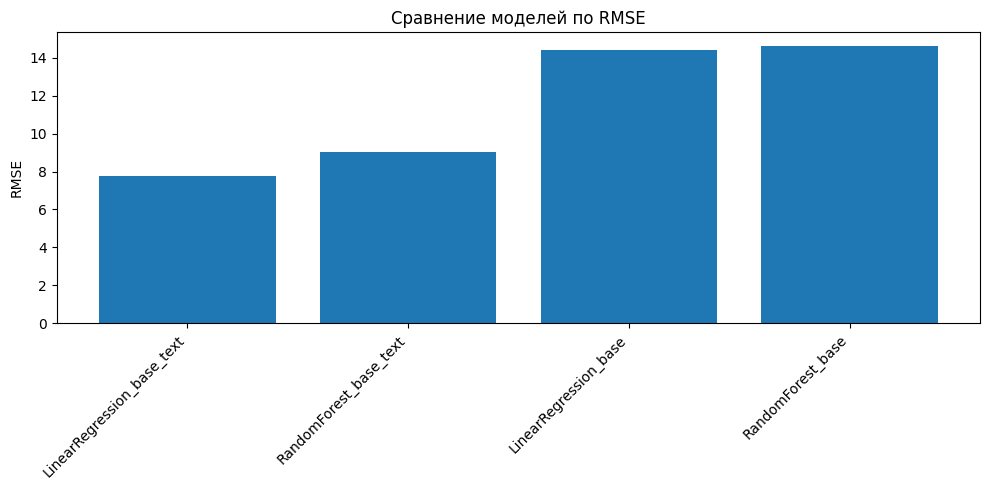

In [31]:
plt.figure(figsize=(10, 5))
plt.bar(results["model"], results["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Сравнение моделей по RMSE")
plt.tight_layout()
plt.show()

Лучшая модель: LinearRegression_base_text


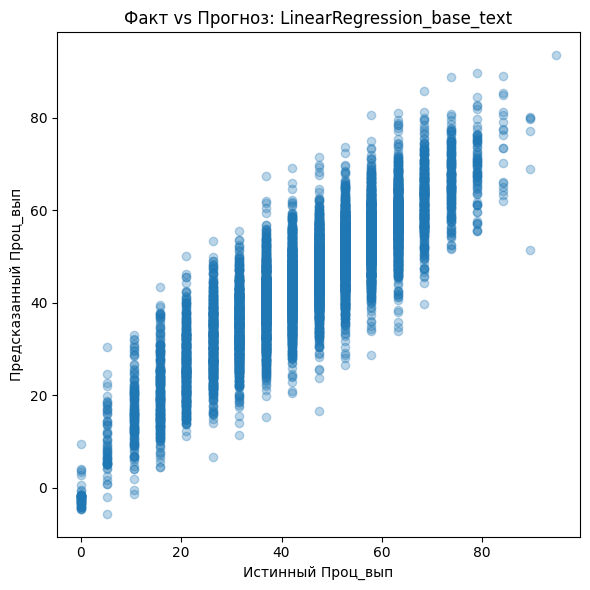

In [32]:
best_model_name = results.iloc[0]["model"]
print("Лучшая модель:", best_model_name)

if best_model_name == "LinearRegression_base":
    best_pred = pred_linear_base
    best_y = y_test
elif best_model_name == "RandomForest_base":
    best_pred = pred_rf_base
    best_y = y_test
elif best_model_name == "LinearRegression_base_text":
    best_pred = pred_linear_text
    best_y = y_test_text
else:
    best_pred = pred_rf_text
    best_y = y_test_text

plt.figure(figsize=(6, 6))
plt.scatter(best_y, best_pred, alpha=0.3)
plt.xlabel("Истинный Проц_вып")
plt.ylabel("Предсказанный Проц_вып")
plt.title(f"Факт vs Прогноз: {best_model_name}")
plt.tight_layout()
plt.show()

## 11. Интерпретация базовой модели Random Forest

In [33]:
rf_base_fitted = rf_base_model.named_steps["model"]
ohe = rf_base_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]

cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_features, cat_feature_names])

rf_importances = pd.DataFrame({
    "feature": all_feature_names,
    "importance": rf_base_fitted.feature_importances_
}).sort_values("importance", ascending=False)

rf_importances.head(20)

,feature,importance
18,Отметка_РУ_3,0.245498
3,Семья_тип2,0.218102
2,Семья_тип,0.162549
0,Члены_семьи,0.065565
26,Отметка_МА_5,0.046418
20,Отметка_РУ_5,0.037455
25,Отметка_МА_4,0.022984
24,Отметка_МА_3,0.016554
11,Размер_НП_4,0.015359
13,Размер_НП_6,0.015270


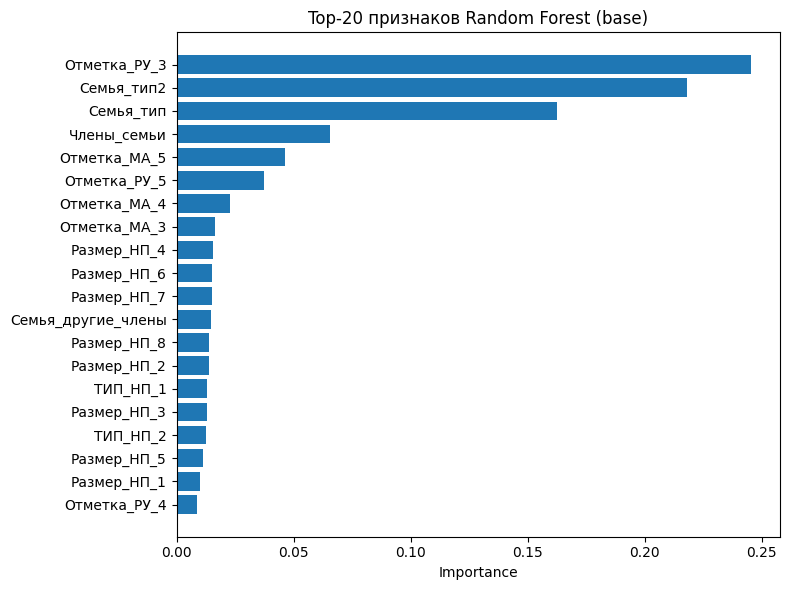

In [34]:
top_rf = rf_importances.head(20).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_rf["feature"], top_rf["importance"])
plt.xlabel("Importance")
plt.title("Top-20 признаков Random Forest (base)")
plt.tight_layout()
plt.show()

## 12. Тест групп признаков на утечку

In [35]:
def evaluate_feature_set(X: pd.DataFrame, y: pd.Series, model_name_prefix: str = "audit"):
    X = X.copy()
    X.columns = X.columns.astype(str)

    num_cols = X.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    for c in cat_cols:
        X[c] = X[c].astype(str)

    X_train, X_test, y_train_loc, y_test_loc = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    for c in cat_cols:
        X_train[c] = X_train[c].astype(str)
        X_test[c] = X_test[c].astype(str)

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_cols)
        ]
    )

    lin_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ])

    rf_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ])

    lin_model.fit(X_train, y_train_loc)
    rf_model.fit(X_train, y_train_loc)

    pred_lin = lin_model.predict(X_test)
    pred_rf = rf_model.predict(X_test)

    return pd.concat([
        regression_metrics(y_test_loc, pred_lin, f"{model_name_prefix}_LinearRegression"),
        regression_metrics(y_test_loc, pred_rf, f"{model_name_prefix}_RandomForest")
    ], ignore_index=True)


In [36]:
audit_results = []

audit_results.append(evaluate_feature_set(X_base, y, "base_only"))

dr_cols_existing = [c for c in dr_cols if c in df.columns]
if len(dr_cols_existing) > 0:
    X_base_plus_dr = pd.concat([X_base, df[dr_cols_existing].copy()], axis=1)
    audit_results.append(evaluate_feature_set(X_base_plus_dr, y, "base_plus_all_DR"))

audit_results_df = pd.concat(audit_results, ignore_index=True).sort_values("RMSE").reset_index(drop=True)
audit_results_df

,model,MAE,RMSE,R2
0,base_plus_all_DR_LinearRegression,0.108954,0.572692,0.998673
1,base_plus_all_DR_RandomForest,0.558564,1.464212,0.991328
2,base_only_LinearRegression,11.619978,14.378268,0.163728
3,base_only_RandomForest,11.782147,14.603216,0.137356


## 13. Сохранение результатов

In [37]:
results.to_csv("model_results_honest.csv", index=False, encoding="utf-8-sig")
rf_importances.to_csv("rf_feature_importance_honest.csv", index=False, encoding="utf-8-sig")
all_cols.to_csv("feature_leakage_audit.csv", index=False, encoding="utf-8-sig")
audit_results_df.to_csv("audit_group_results.csv", index=False, encoding="utf-8-sig")

print("Результаты сохранены.")

Результаты сохранены.


In [38]:
best_row = results.iloc[0]

print("Лучший результат показала модель:", best_row["model"])
print(f"MAE = {best_row['MAE']:.4f}")
print(f"RMSE = {best_row['RMSE']:.4f}")
print(f"R2 = {best_row['R2']:.4f}")

Лучший результат показала модель: LinearRegression_base_text
MAE = 6.1301
RMSE = 7.7752
R2 = 0.7555


---

In [39]:
from collections import defaultdict

dr_groups = defaultdict(list)

for col in dr_cols:
    group = str(col).split(".")[0]   # ДР1, ДР2, ДР3 ...
    dr_groups[group].append(col)

for group in sorted(dr_groups.keys(), key=lambda x: int(x.replace("ДР", ""))):
    print(group, "->", len(dr_groups[group]), "признаков")
    print(sorted(dr_groups[group]))
    print()

ДР1 -> 10 признаков
['ДР1.1', 'ДР1.2_1', 'ДР1.2_2', 'ДР1.2_3', 'ДР1.2_4', 'ДР1.2_5', 'ДР1.2_6', 'ДР1.2_7', 'ДР1.2_8', 'ДР1.2_9']

ДР2 -> 1 признаков
['ДР2']

ДР3 -> 7 признаков
['ДР3.1', 'ДР3.2_0', 'ДР3.2_1', 'ДР3.2_2', 'ДР3.2_3', 'ДР3.2_4', 'ДР3.2_5']

ДР5 -> 1 признаков
['ДР5']

ДР6 -> 9 признаков
['ДР6.1', 'ДР6.2_1', 'ДР6.2_2', 'ДР6.2_3', 'ДР6.2_4', 'ДР6.2_5', 'ДР6.2_6', 'ДР6.2_7', 'ДР6.3']

ДР7 -> 8 признаков
['ДР7.1', 'ДР7.2_0', 'ДР7.2_1', 'ДР7.2_2', 'ДР7.2_3', 'ДР7.2_4', 'ДР7.2_5', 'ДР7.2_6']

ДР8 -> 7 признаков
['ДР8.1', 'ДР8.2_1', 'ДР8.2_2', 'ДР8.2_3', 'ДР8.2_4', 'ДР8.2_5', 'ДР8.2_6']

ДР9 -> 7 признаков
['ДР9.1', 'ДР9.2_0', 'ДР9.2_1', 'ДР9.2_2', 'ДР9.2_3', 'ДР9.2_4', 'ДР9.2_5']

ДР10 -> 8 признаков
['ДР10.1', 'ДР10.2_0', 'ДР10.2_1', 'ДР10.2_2', 'ДР10.2_3', 'ДР10.2_4', 'ДР10.2_5', 'ДР10.2_6']

ДР4_1 -> 1 признаков
['ДР4_1']

ДР4_2 -> 1 признаков
['ДР4_2']

ДР4_3 -> 1 признаков
['ДР4_3']

ДР4_4 -> 1 признаков
['ДР4_4']

ДР4_5 -> 1 признаков
['ДР4_5']

ДР4_6 -> 1 признаков
['ДР4_

In [40]:
def audit_one_dr_group(group_name, X_base, df, y):
    cols = [c for c in dr_groups[group_name] if c in df.columns]
    
    if len(cols) == 0:
        return None

    X_group = pd.concat([X_base.copy(), df[cols].copy()], axis=1)
    result = evaluate_feature_set(X_group, y, f"{group_name}_added")
    result["group"] = group_name
    result["n_group_features"] = len(cols)
    return result

In [41]:
group_audit_results = []

for group_name in sorted(dr_groups.keys(), key=lambda x: int(x.replace("ДР", ""))):
    res = audit_one_dr_group(group_name, X_base, df, y)
    if res is not None:
        group_audit_results.append(res)

group_audit_df = pd.concat(group_audit_results, ignore_index=True)
group_audit_df = group_audit_df.sort_values(["RMSE", "R2"], ascending=[True, False]).reset_index(drop=True)

group_audit_df

,model,MAE,RMSE,R2,group,n_group_features
0,ДР6_added_LinearRegression,8.765101,10.801408,0.528051,ДР6,9
1,ДР6_added_RandomForest,9.056123,11.180391,0.494352,ДР6,9
2,ДР10_added_LinearRegression,9.486263,11.714372,0.444898,ДР10,8
3,ДР2_added_LinearRegression,9.798786,12.119455,0.405844,ДР2,1
4,ДР10_added_RandomForest,9.791838,12.120422,0.405749,ДР10,8
5,ДР9_added_LinearRegression,9.956787,12.328134,0.385207,ДР9,7
6,ДР7_added_LinearRegression,10.092608,12.425293,0.375478,ДР7,8
7,ДР2_added_RandomForest,10.080010,12.519901,0.365931,ДР2,1
8,ДР8_added_LinearRegression,10.192796,12.567833,0.361067,ДР8,7
9,ДР9_added_RandomForest,10.169260,12.651632,0.352518,ДР9,7


In [42]:
group_audit_df[group_audit_df["model"].str.contains("LinearRegression")].sort_values("RMSE").reset_index(drop=True)

,model,MAE,RMSE,R2,group,n_group_features
0,ДР6_added_LinearRegression,8.765101,10.801408,0.528051,ДР6,9
1,ДР10_added_LinearRegression,9.486263,11.714372,0.444898,ДР10,8
2,ДР2_added_LinearRegression,9.798786,12.119455,0.405844,ДР2,1
3,ДР9_added_LinearRegression,9.956787,12.328134,0.385207,ДР9,7
4,ДР7_added_LinearRegression,10.092608,12.425293,0.375478,ДР7,8
5,ДР8_added_LinearRegression,10.192796,12.567833,0.361067,ДР8,7
6,ДР3_added_LinearRegression,10.304664,12.744411,0.342987,ДР3,7
7,ДР5_added_LinearRegression,10.991066,13.594712,0.252391,ДР5,1
8,ДР4_1_added_LinearRegression,11.055937,13.668996,0.244199,ДР4_1,1
9,ДР4_8_added_LinearRegression,11.070750,13.684851,0.242444,ДР4_8,1


In [43]:
group_audit_df[group_audit_df["model"].str.contains("RandomForest")].sort_values("RMSE").reset_index(drop=True)

,model,MAE,RMSE,R2,group,n_group_features
0,ДР6_added_RandomForest,9.056123,11.180391,0.494352,ДР6,9
1,ДР10_added_RandomForest,9.791838,12.120422,0.405749,ДР10,8
2,ДР2_added_RandomForest,10.080010,12.519901,0.365931,ДР2,1
3,ДР9_added_RandomForest,10.169260,12.651632,0.352518,ДР9,7
4,ДР7_added_RandomForest,10.429413,12.907629,0.326050,ДР7,8
5,ДР8_added_RandomForest,10.447239,12.932335,0.323468,ДР8,7
6,ДР3_added_RandomForest,10.663759,13.207807,0.294339,ДР3,7
7,ДР5_added_RandomForest,11.187388,13.890700,0.219482,ДР5,1
8,ДР4_8_added_RandomForest,11.254649,13.941691,0.213741,ДР4_8,1
9,ДР4_1_added_RandomForest,11.450578,14.207941,0.183424,ДР4_1,1


In [44]:
suspicious_groups = group_audit_df[group_audit_df["R2"] > 0.8].copy()
suspicious_groups.sort_values(["R2", "RMSE"], ascending=[False, True]).reset_index(drop=True)

,model,MAE,RMSE,R2,group,n_group_features


In [45]:
suspicious_group_names = suspicious_groups["group"].dropna().unique().tolist()

print("Подозрительные группы:")
print(suspicious_group_names)

for group_name in suspicious_group_names:
    print("\n" + "=" * 100)
    print(group_name)
    print(sorted(dr_groups[group_name]))

Подозрительные группы:
[]


In [46]:
group_audit_df.to_csv("group_audit_dr_results.csv", index=False, encoding="utf-8-sig")
print("Сохранено: group_audit_dr_results.csv")

Сохранено: group_audit_dr_results.csv


In [47]:
def audit_dr_combination(group_names, X_base, df, y):
    cols = []
    for g in group_names:
        cols.extend([c for c in dr_groups[g] if c in df.columns])

    cols = list(dict.fromkeys(cols))

    X_combo = pd.concat([X_base.copy(), df[cols].copy()], axis=1)
    result = evaluate_feature_set(X_combo, y, "_plus_".join(group_names))
    result["groups"] = ", ".join(group_names)
    result["n_groups"] = len(group_names)
    result["n_features_added"] = len(cols)
    return result

In [48]:
combo_list = [
    ["ДР2", "ДР6"],
    ["ДР2", "ДР10"],
    ["ДР6", "ДР10"],
    ["ДР2", "ДР6", "ДР10"],
    
    ["ДР7", "ДР8"],
    ["ДР7", "ДР9"],
    ["ДР8", "ДР9"],
    ["ДР7", "ДР8", "ДР9"],
    
    ["ДР2", "ДР6", "ДР7", "ДР10"],
    ["ДР2", "ДР6", "ДР8", "ДР10"],
    ["ДР2", "ДР6", "ДР9", "ДР10"],
]
combo_list

[['ДР2', 'ДР6'],
 ['ДР2', 'ДР10'],
 ['ДР6', 'ДР10'],
 ['ДР2', 'ДР6', 'ДР10'],
 ['ДР7', 'ДР8'],
 ['ДР7', 'ДР9'],
 ['ДР8', 'ДР9'],
 ['ДР7', 'ДР8', 'ДР9'],
 ['ДР2', 'ДР6', 'ДР7', 'ДР10'],
 ['ДР2', 'ДР6', 'ДР8', 'ДР10'],
 ['ДР2', 'ДР6', 'ДР9', 'ДР10']]

In [49]:
combo_results = []

for combo in combo_list:
    res = audit_dr_combination(combo, X_base, df, y)
    combo_results.append(res)

combo_results_df = pd.concat(combo_results, ignore_index=True)
combo_results_df = combo_results_df.sort_values(["RMSE", "R2"], ascending=[True, False]).reset_index(drop=True)

combo_results_df

,model,MAE,RMSE,R2,groups,n_groups,n_features_added
0,ДР2_plus_ДР6_plus_ДР7_plus_ДР10_LinearRegression,4.297800,5.386066,0.882651,"ДР2, ДР6, ДР7, ДР10",4,26
1,ДР2_plus_ДР6_plus_ДР9_plus_ДР10_LinearRegression,4.368330,5.493364,0.877929,"ДР2, ДР6, ДР9, ДР10",4,25
2,ДР2_plus_ДР6_plus_ДР8_plus_ДР10_LinearRegression,4.489278,5.626418,0.871944,"ДР2, ДР6, ДР8, ДР10",4,25
3,ДР2_plus_ДР6_plus_ДР7_plus_ДР10_RandomForest,4.484570,5.661119,0.870360,"ДР2, ДР6, ДР7, ДР10",4,26
4,ДР2_plus_ДР6_plus_ДР9_plus_ДР10_RandomForest,4.574248,5.741616,0.866647,"ДР2, ДР6, ДР9, ДР10",4,25
5,ДР2_plus_ДР6_plus_ДР8_plus_ДР10_RandomForest,4.706713,5.911559,0.858636,"ДР2, ДР6, ДР8, ДР10",4,25
6,ДР2_plus_ДР6_plus_ДР10_LinearRegression,5.142515,6.446736,0.831882,"ДР2, ДР6, ДР10",3,18
7,ДР2_plus_ДР6_plus_ДР10_RandomForest,5.376231,6.743863,0.816028,"ДР2, ДР6, ДР10",3,18
8,ДР2_plus_ДР6_LinearRegression,6.854545,8.517617,0.706525,"ДР2, ДР6",2,10
9,ДР2_plus_ДР6_RandomForest,7.125883,8.878068,0.681161,"ДР2, ДР6",2,10


In [50]:
combo_results_df[combo_results_df["model"].str.contains("LinearRegression")].sort_values("RMSE").reset_index(drop=True)

,model,MAE,RMSE,R2,groups,n_groups,n_features_added
0,ДР2_plus_ДР6_plus_ДР7_plus_ДР10_LinearRegression,4.297800,5.386066,0.882651,"ДР2, ДР6, ДР7, ДР10",4,26
1,ДР2_plus_ДР6_plus_ДР9_plus_ДР10_LinearRegression,4.368330,5.493364,0.877929,"ДР2, ДР6, ДР9, ДР10",4,25
2,ДР2_plus_ДР6_plus_ДР8_plus_ДР10_LinearRegression,4.489278,5.626418,0.871944,"ДР2, ДР6, ДР8, ДР10",4,25
3,ДР2_plus_ДР6_plus_ДР10_LinearRegression,5.142515,6.446736,0.831882,"ДР2, ДР6, ДР10",3,18
4,ДР2_plus_ДР6_LinearRegression,6.854545,8.517617,0.706525,"ДР2, ДР6",2,10
5,ДР6_plus_ДР10_LinearRegression,7.332117,9.000536,0.672304,"ДР6, ДР10",2,17
6,ДР2_plus_ДР10_LinearRegression,7.622874,9.433138,0.640046,"ДР2, ДР10",2,9
7,ДР7_plus_ДР8_plus_ДР9_LinearRegression,8.045069,9.944329,0.599977,"ДР7, ДР8, ДР9",3,22
8,ДР7_plus_ДР9_LinearRegression,8.781445,10.851546,0.523659,"ДР7, ДР9",2,15
9,ДР7_plus_ДР8_LinearRegression,8.941177,11.019193,0.508827,"ДР7, ДР8",2,15


In [51]:
combo_results_df[combo_results_df["model"].str.contains("RandomForest")].sort_values("RMSE").reset_index(drop=True)

,model,MAE,RMSE,R2,groups,n_groups,n_features_added
0,ДР2_plus_ДР6_plus_ДР7_plus_ДР10_RandomForest,4.484570,5.661119,0.870360,"ДР2, ДР6, ДР7, ДР10",4,26
1,ДР2_plus_ДР6_plus_ДР9_plus_ДР10_RandomForest,4.574248,5.741616,0.866647,"ДР2, ДР6, ДР9, ДР10",4,25
2,ДР2_plus_ДР6_plus_ДР8_plus_ДР10_RandomForest,4.706713,5.911559,0.858636,"ДР2, ДР6, ДР8, ДР10",4,25
3,ДР2_plus_ДР6_plus_ДР10_RandomForest,5.376231,6.743863,0.816028,"ДР2, ДР6, ДР10",3,18
4,ДР2_plus_ДР6_RandomForest,7.125883,8.878068,0.681161,"ДР2, ДР6",2,10
5,ДР6_plus_ДР10_RandomForest,7.549621,9.310914,0.649313,"ДР6, ДР10",2,17
6,ДР2_plus_ДР10_RandomForest,7.916936,9.866139,0.606242,"ДР2, ДР10",2,9
7,ДР7_plus_ДР8_plus_ДР9_RandomForest,8.362332,10.363613,0.565533,"ДР7, ДР8, ДР9",3,22
8,ДР7_plus_ДР9_RandomForest,9.111473,11.315182,0.482086,"ДР7, ДР9",2,15
9,ДР7_plus_ДР8_RandomForest,9.288490,11.496901,0.465317,"ДР7, ДР8",2,15


In [52]:
suspicious_combos = combo_results_df[combo_results_df["R2"] > 0.8].copy()
suspicious_combos.sort_values(["R2", "RMSE"], ascending=[False, True]).reset_index(drop=True)

,model,MAE,RMSE,R2,groups,n_groups,n_features_added
0,ДР2_plus_ДР6_plus_ДР7_plus_ДР10_LinearRegression,4.297800,5.386066,0.882651,"ДР2, ДР6, ДР7, ДР10",4,26
1,ДР2_plus_ДР6_plus_ДР9_plus_ДР10_LinearRegression,4.368330,5.493364,0.877929,"ДР2, ДР6, ДР9, ДР10",4,25
2,ДР2_plus_ДР6_plus_ДР8_plus_ДР10_LinearRegression,4.489278,5.626418,0.871944,"ДР2, ДР6, ДР8, ДР10",4,25
3,ДР2_plus_ДР6_plus_ДР7_plus_ДР10_RandomForest,4.484570,5.661119,0.870360,"ДР2, ДР6, ДР7, ДР10",4,26
4,ДР2_plus_ДР6_plus_ДР9_plus_ДР10_RandomForest,4.574248,5.741616,0.866647,"ДР2, ДР6, ДР9, ДР10",4,25
5,ДР2_plus_ДР6_plus_ДР8_plus_ДР10_RandomForest,4.706713,5.911559,0.858636,"ДР2, ДР6, ДР8, ДР10",4,25
6,ДР2_plus_ДР6_plus_ДР10_LinearRegression,5.142515,6.446736,0.831882,"ДР2, ДР6, ДР10",3,18
7,ДР2_plus_ДР6_plus_ДР10_RandomForest,5.376231,6.743863,0.816028,"ДР2, ДР6, ДР10",3,18


In [53]:
useful_combos = combo_results_df[
    (combo_results_df["R2"] > 0.3) & (combo_results_df["R2"] <= 0.8)
].copy()

useful_combos.sort_values(["R2", "RMSE"], ascending=[False, True]).reset_index(drop=True)

,model,MAE,RMSE,R2,groups,n_groups,n_features_added
0,ДР2_plus_ДР6_LinearRegression,6.854545,8.517617,0.706525,"ДР2, ДР6",2,10
1,ДР2_plus_ДР6_RandomForest,7.125883,8.878068,0.681161,"ДР2, ДР6",2,10
2,ДР6_plus_ДР10_LinearRegression,7.332117,9.000536,0.672304,"ДР6, ДР10",2,17
3,ДР6_plus_ДР10_RandomForest,7.549621,9.310914,0.649313,"ДР6, ДР10",2,17
4,ДР2_plus_ДР10_LinearRegression,7.622874,9.433138,0.640046,"ДР2, ДР10",2,9
5,ДР2_plus_ДР10_RandomForest,7.916936,9.866139,0.606242,"ДР2, ДР10",2,9
6,ДР7_plus_ДР8_plus_ДР9_LinearRegression,8.045069,9.944329,0.599977,"ДР7, ДР8, ДР9",3,22
7,ДР7_plus_ДР8_plus_ДР9_RandomForest,8.362332,10.363613,0.565533,"ДР7, ДР8, ДР9",3,22
8,ДР7_plus_ДР9_LinearRegression,8.781445,10.851546,0.523659,"ДР7, ДР9",2,15
9,ДР7_plus_ДР8_LinearRegression,8.941177,11.019193,0.508827,"ДР7, ДР8",2,15


In [54]:
combo_results_df.to_csv("combo_audit_dr_results.csv", index=False, encoding="utf-8-sig")
print("Сохранено: combo_audit_dr_results.csv")

Сохранено: combo_audit_dr_results.csv
